# Import the packages

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
import scipy.linalg as la
import matplotlib.pyplot as plt
import emcee
import corner
import os
import time
from multiprocess import Pool, cpu_count

# Load the Dataset and Covariance Matrix

In [2]:
# Load the main dataset
data_file_path = '../../data/Pantheon+SH0ES.dat'
try:
    df = pd.read_csv(data_file_path, sep=r'\s+')
    N_data = len(df)
    print(f"Dataset loaded successfully. Total supernovae: {N_data}")
except FileNotFoundError:
    print(f"Error: The file {data_file_path} was not found.")

# Load and prepare the Covariance Matrix
cov_file_path = '../../data/Pantheon+SH0ES_STAT+SYS.cov' 
try:
    with open(cov_file_path, 'r') as f:
        lines = f.readlines()
    if len(lines[0].split()) == 1:
        lines = lines[1:]
        
    cov_1d = np.loadtxt(lines)
    C = cov_1d.reshape((N_data, N_data))
    
    # Cholesky decomposition for safe inversion and log-determinant
    c_chol, lower = la.cho_factor(C)
    C_inv = la.cho_solve((c_chol, lower), np.eye(N_data))
    log_det_C = 2.0 * np.sum(np.log(np.diag(c_chol)))
    
    print("Covariance matrix loaded, inverted, and log-determinant calculated.")
except FileNotFoundError:
    print(f"Error: The file {cov_file_path} was not found.")

Dataset loaded successfully. Total supernovae: 1701
Covariance matrix loaded, inverted, and log-determinant calculated.


# Define Physics Model

In [3]:
c = 299792.458 # Speed of light in km/s

def model_calibrators(M_B, mu_ceph):
    return M_B + mu_ceph

def E_inverse(z, Omega_m):
    Omega_L = 1.0 - Omega_m
    return 1.0 / np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m):
    integral, _ = quad(E_inverse, 0, z_cmb, args=(Omega_m,))
    return (c / H_0) * (1 + z_hel) * integral

def model_cosmology(z_hel, z_cmb, M_B, H_0, Omega_m):
    d_L_mpc = luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m)
    mu_lcdm = 5.0 * np.log10(d_L_mpc) + 25.0
    return M_B + mu_lcdm

# Define the Bayesian Framework (Prior, Likelihood, Posterior)

In [4]:
def build_residual_vector(params, data):
    Omega_m, H_0, M_B = params
    delta = np.zeros(len(data))
    
    for i, row in data.iterrows():
        m_b_obs = row['m_b_corr']
        if row['IS_CALIBRATOR'] == 1 and row['CEPH_DIST'] > -9:
            m_b_th = model_calibrators(M_B, row['CEPH_DIST'])
        else:
            m_b_th = model_cosmology(row['zHEL'], row['zCMB'], M_B, H_0, Omega_m)
        delta[i] = m_b_obs - m_b_th
    return delta

def log_likelihood(params, data, C_inv, log_det_C):
    """Computes the true ln(L) for MCMC (not negative)"""
    delta = build_residual_vector(params, data)
    chi2 = np.dot(delta.T, np.dot(C_inv, delta))
    N_obs = len(data)
    ln_L = -0.5 * (chi2 + log_det_C + N_obs * np.log(2 * np.pi))
    return ln_L

def log_prior(params):
    Omega_m, H_0, M_B = params
    if (0.01 < Omega_m < 0.99) and (50.0 < H_0 < 100.0) and (-21.0 < M_B < -18.0):
        return 0.0 # log(1) = 0 for uniform prior
    return -np.inf # log(0) = -inf for regions outside the prior

def log_posterior(params, data, C_inv, log_det_C):
    """ ln P(theta | data) = ln prior(theta) + ln L(data | theta) """
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, data, C_inv, log_det_C)

# Run the MCMC Chain

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"

if __name__ == '__main__':
    print("Initializing MCMC Walkers...")
    
    # Dimensionality of the parameter space (Omega_m, H_0, M_B)
    ndim = 3 
    
    # Number of MCMC walkers (Best practice: make this a multiple of your CPU cores)
    nwalkers = 15 
    
    # Initialize walkers around the best-fit values from Week 4
    best_fit_guess = np.array([0.33, 73.0, -19.24])
    initial_pos = best_fit_guess + 1e-4 * np.random.randn(nwalkers, ndim)
    
    # Set up the backend to save the chain to disk safely
    filename = "mcmc_chains/pantheon_mcmc_chain.h5"
    backend = emcee.backends.HDFBackend(filename)
    backend.reset(nwalkers, ndim)
    
    nsteps = 1000
    ncpu = max(1, cpu_count() - 2)
 
    print(f"Detected {cpu_count()} CPU cores. Setting up parallel pool...")
    
    # Use a multiprocessing Pool context manager
    start_time = time.time()
    with Pool(processes=ncpu) as pool:
        # Initialize the emcee EnsembleSampler with the pool argument
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            log_posterior, 
            args=(df, C_inv, log_det_C),
            pool=pool,          # <--- This single argument enables parallelization
            backend=backend
        )
    
        print(f"Running MCMC for {nsteps} steps across {ncpu} cores...")
        sampler.run_mcmc(initial_pos, nsteps, progress=True)
    
    end_time = time.time()
    print(f"\nMCMC run complete and saved to disk.")
    print(f"Total time taken: {(end_time - start_time) / 60:.2f} minutes.")
#

Initializing MCMC Walkers...
Detected 20 CPU cores. Setting up parallel pool...
Running MCMC for 1000 steps across 18 cores...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [20:53<00:00,  1.25s/it]


MCMC run complete and saved to disk.
Total time taken: 20.92 minutes.


# Discard Burn-in and Compute Posterior

In [6]:
# We discard the first 300 steps of each walker as "burn-in" 
# (time taken for walkers to forget their initial positions and reach the true posterior)
discard_steps = 300
thin_steps = 15 # Thinning to reduce autocorrelation

# Flatten the chain into a single 2D array of samples
flat_samples = sampler.get_chain(discard=discard_steps, thin=thin_steps, flat=True)

print(f"Total number of useful samples generated: {len(flat_samples)}")

# Calculate the median and 16th/84th percentiles (1-sigma intervals)
labels = [r"\Omega_m", r"H_0", r"M_B"]
results = {}

print("\n--- Parameter Constraints (Median ± 1-sigma) ---")
for i in range(ndim):
    mcmc_samples = flat_samples[:, i]
    median = np.percentile(mcmc_samples, 50)
    lower_error = median - np.percentile(mcmc_samples, 16)
    upper_error = np.percentile(mcmc_samples, 84) - median
    
    results[labels[i]] = (median, lower_error, upper_error)
    print(f"{labels[i]}: {median:.4f} +{upper_error:.4f} / -{lower_error:.4f}")

Total number of useful samples generated: 690

--- Parameter Constraints (Median ± 1-sigma) ---
\Omega_m: 0.3484 +0.0184 / -0.0192
H_0: 72.7063 +1.0994 / -0.8913
M_B: -19.2563 +0.0321 / -0.0236


Generating corner plot...
Corner plot successfully saved as plots/week5_corner_plot.png


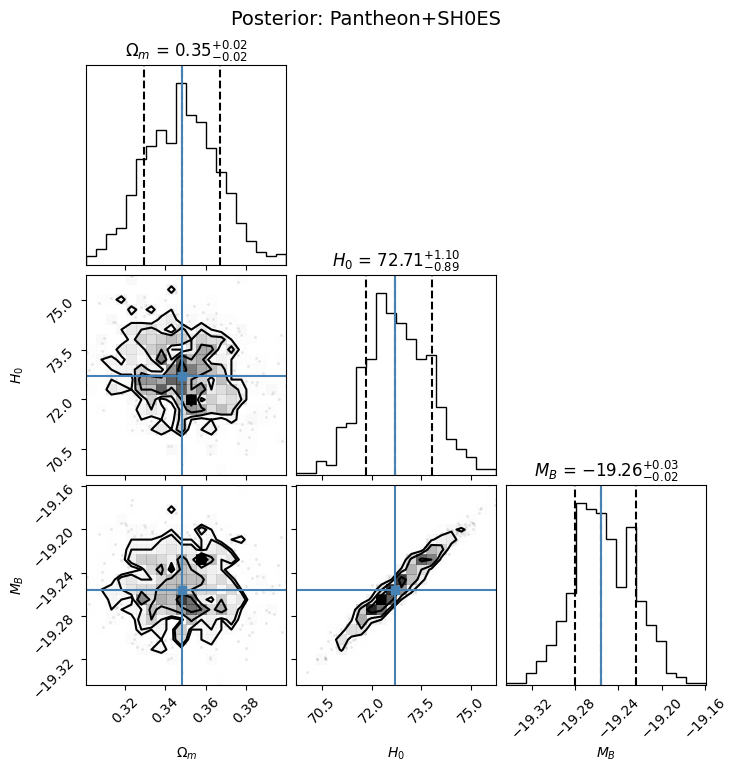

In [7]:
print("Generating corner plot...")
fig = corner.corner(
    flat_samples, 
    labels=[r"$\Omega_m$", r"$H_0$", r"$M_B$"], 
    truths=[results[r"\Omega_m"][0], results[r"H_0"][0], results[r"M_B"][0]],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)
plt.suptitle("Posterior: Pantheon+SH0ES", y=1.02, fontsize=14)
save_filename = "plots/week5_corner_plot.png"
plt.savefig(save_filename, dpi=300, bbox_inches='tight')
print(f"Corner plot successfully saved as {save_filename}")

plt.show()